# 03 — PID selector optimization (Punzi figure of merit)

**Stage 3 checkpoint notebook** for the BNV searches
$B^0 \to \Lambda^0 \Lambda^0$ and $B^+ \to \Lambda_c^+ \Lambda^0$.

Uses **MC only** (signal + luminosity-weighted background) -- no collision
data is read, same as Stage 2. This notebook:

1. scans the KM-family selector ladder (`pid_selector.KM_LADDER`, Super Loose
   -> Super Tight) for the $\Lambda^0$ proton/pion daughters (both channels),
   on top of the current Stage 1/2 selection (single-candidate + fit region +
   purity cuts, whatever is presently in `channel_config.py`);
2. (`Lam0LamC` only) does the same for each $\Lambda_c^+$ decay mode's own
   daughters, independently per mode, with the $\Lambda^0$ recommendation
   from step 1 fixed and reused for mode 4's inner $\Lambda^0$ (sequential
   optimization, same spirit as Stage 2's $K_S^0$-before-$\Lambda_c^+$
   ordering);
3. (`Lam0LamC` only) redoes the multi-candidate study with the Stage 3
   recommended PID cuts folded in on top of Stage 2's purity cuts --
   **numbers only**, no candidate-selection policy (STATUS.md open decision 1).

The figure of merit is the Punzi FOM (verified against
`BNV_pLambda/PID_study_and_plots_for_BAD.ipynb`, not guessed):
$\mathrm{FOM} = \epsilon_{\rm sig} / \sqrt{B + a/2}$, $a=4$. $\epsilon_{\rm
sig}$ is the signal-MC efficiency of the PID cut *on top of* the current
Stage 1/2 selection (i.e. the PID cut's own marginal effect); $B$ is the
luminosity-weighted count of background MC (all of
`channel_config.BACKGROUND_SP_MODES`) surviving the same selection, directly
in the mES/$\Delta E$ signal region -- an MC-truth background estimate, not
a sideband one (Stage 5/6 will do the data-driven sideband estimate).

The PID ladder is discrete, unlike Stage 2's continuous scans, but the same
boundary-hugging concern applies: `purity_optimization.is_at_scan_boundary`
is reused by treating each ladder as integer rungs. A second, PID-specific
failure mode is also flagged: at a tight enough selector, the weighted
background estimate can collapse toward zero on very few raw MC candidates,
inflating the FOM from a noisy denominator (`low_mc_stats`).

This notebook does **not** modify `channel_config.py`. It prints the
recommended selectors for the human to review at the checkpoint; the same
computation is performed (and written to `results/<channel>.yaml`) by
`run_stage03.py`, which this notebook imports directly (`summarize_ladder_result`,
`multi_candidate_numbers_with_pid`) so the two cannot diverge.

In [1]:
import sys
sys.path.insert(0, '..')

get_ipython().run_line_magic('load_ext', 'autoreload')
get_ipython().run_line_magic('autoreload', '2')

import numpy as np
import awkward as ak
import pandas as pd
import matplotlib.pylab as plt

from channel_config import get_channel_config, BACKGROUND_SP_MODES, SIGNAL_SP_MODE
import datasets
import cutflow
import pid_selector
import pid_optimization as po
import plotting
import results_io
import run_stage03 as rs3

In [2]:
# Select the channel here: 'Lam0Lam0' or 'Lam0LamC'
CHANNEL = 'Lam0LamC'

config = get_channel_config(CHANNEL)
print(f"Channel: {config['name']}   {config['decay_label']}")

Channel: Lam0LamC   $B^+ \to \Lambda_c^+ \Lambda^0$


## Load signal + background MC only

No collision data is opened in this notebook (`sp_or_data='sp'`) -- the PID
optimization must not look at data, per the Stage 3 plan.

In [3]:
data_sp, _ = datasets.load_datasets(CHANNEL, sp_or_data='sp')
datasets.add_derived_fields(data_sp, config)

weights = datasets.get_scaling_weights(BACKGROUND_SP_MODES)

# Current Stage 1/2 selection (purity cuts, no PID) -- both the Punzi FOM's
# signal-efficiency numerator/denominator and its background count are
# computed on top of this, so the FOM measures each PID cut's marginal effect.
baseline_mask = cutflow.get_composite_purity_masks_per_B(data_sp, config)

print(f"MC (SP) events: {len(data_sp)}")
print(f"Background scaling weights: {weights}")

Opening /home/bellis/BaBar_BNV_2Lambda_Claude_experiment/data/Background_and_signal_SP_modes_All_runs_Lam0LamC.parquet...
Took 127.729 seconds

Added derived fields for channel Lam0LamC
MC (SP) events: 286890
Background scaling weights: {'998': 0.2506879075487834, '1005': 0.49619965664110677, '1235': 0.3191592629119508, '1237': 0.31492522877218293, '3429': 0.24466843736502886}


## $\Lambda^0$ PID scan (both channels)

2D grid over the proton x pion KM ladders. Reused as-is for `Lam0LamC`'s
LambdaC mode 4, whose inner $\Lambda^0$ shares this same selector choice
rather than being re-scanned.

Lambda0 PID: recommended {'p': 'SuperLooseKMProtonSelection', 'pi': 'SuperLooseKMPionMicroSelection'}
  FOM=0.082  sig_eff=0.968  bkg(weighted)=135.97  bkg(raw MC)=333
  at_scan_boundary={'p_selector_idx': True, 'pi_selector_idx': True}  low_mc_stats=False


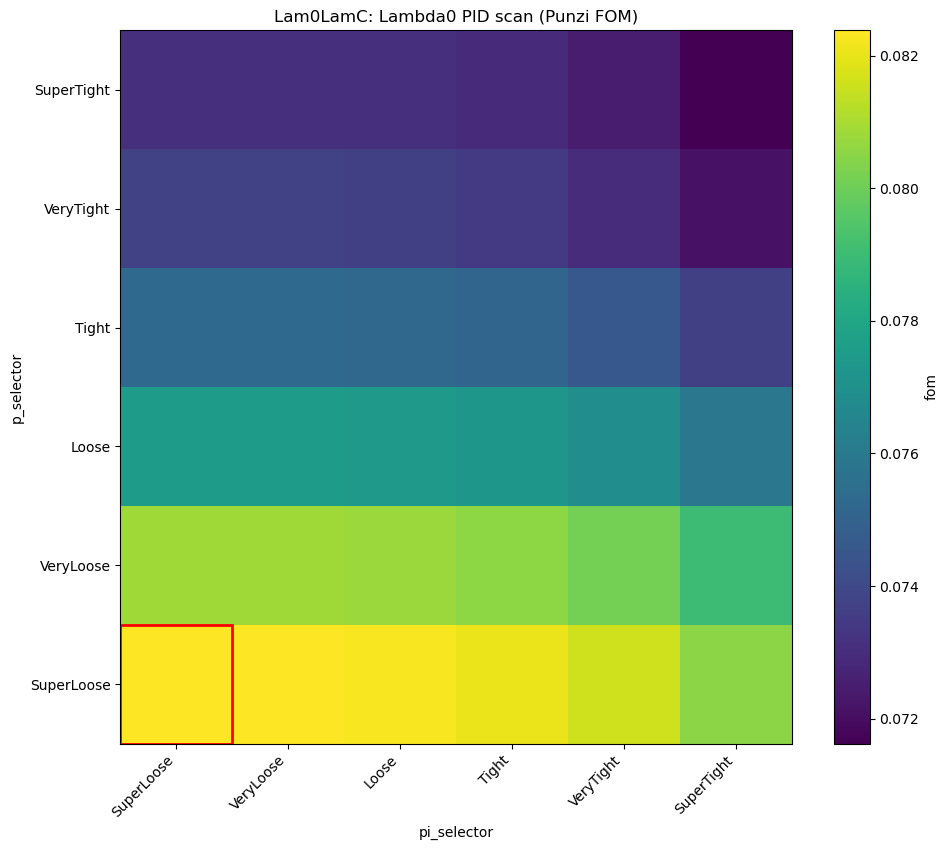

In [4]:
l0_ladders = {'p': pid_selector.KM_LADDER['p'], 'pi': pid_selector.KM_LADDER['pi']}

df_l0 = po.scan_lambda0_pid(data_sp, config, weights, baseline_mask, l0_ladders['p'], l0_ladders['pi'])
best_l0 = po.best_from_ladder_scan(df_l0, ['p_selector_idx', 'pi_selector_idx'])
lambda0_summary = rs3.summarize_ladder_result(df_l0, best_l0, l0_ladders)
lambda0_selector = lambda0_summary['recommended_selector']

print(f"Lambda0 PID: recommended {lambda0_selector}")
print(f"  FOM={lambda0_summary['fom_at_recommended']:.3f}  "
      f"sig_eff={lambda0_summary['sig_eff_at_recommended']:.3f}  "
      f"bkg(weighted)={lambda0_summary['bkg_weighted_at_recommended']:.2f}  "
      f"bkg(raw MC)={lambda0_summary['bkg_raw_mc_at_recommended']}")
print(f"  at_scan_boundary={lambda0_summary['at_scan_boundary']}  "
      f"low_mc_stats={lambda0_summary['low_mc_stats_at_recommended']}")

plotting.plot_pid_ladder_scan_2d(df_l0, 'p_selector', 'p_selector_idx', 'pi_selector', 'pi_selector_idx',
                                  chosen=(lambda0_selector['p'], lambda0_selector['pi']),
                                  title=f'{CHANNEL}: Lambda0 PID scan (Punzi FOM)')
plt.savefig(f"{plotting.plot_dir(config)}/lambda0_pid_scan.png", dpi=150)

In [5]:
# Sanity check: does the recommended (loosest, if boundary-hugging) selector
# actually beat applying *no* PID cut at all, or does the true optimum lie
# outside the scanned ladder entirely?
no_pid_mask = ak.ones_like(baseline_mask, dtype=bool)
no_pid_result = po.evaluate_combo(data_sp, config, weights, baseline_mask, no_pid_mask)

print(f"No PID at all:            FOM={no_pid_result['fom']:.4f}  sig_eff={no_pid_result['sig_eff']:.3f}  "
      f"bkg={no_pid_result['bkg_weighted']:.2f}")
print(f"Recommended {lambda0_selector}:")
print(f"                          FOM={lambda0_summary['fom_at_recommended']:.4f}  "
      f"sig_eff={lambda0_summary['sig_eff_at_recommended']:.3f}  "
      f"bkg={lambda0_summary['bkg_weighted_at_recommended']:.2f}")

No PID at all:            FOM=0.0811  sig_eff=1.000  bkg=150.02
Recommended {'p': 'SuperLooseKMProtonSelection', 'pi': 'SuperLooseKMPionMicroSelection'}:
                          FOM=0.0824  sig_eff=0.968  bkg=135.97


## $\Lambda_c^+$ PID scans, per decay mode (`Lam0LamC` only)

The daughter slots scanned differ by mode (verified empirically against
`LambdaCdNLund` on signal MC -- see STATUS.md Stage 3 notes): mode 1 needs
p+K+pi, mode 2 needs p only, mode 3 needs p+pi, mode 4 needs pi (its own
three pions) plus the inner $\Lambda^0$'s p/pi, which reuses the selector
chosen above rather than being re-scanned. Each mode's scan is restricted to
candidates whose LambdaC daughter is that decay mode
(`cutflow.get_lambdac_decay_mode_per_B`), so the four ladders are optimized
independently of each other.

In [6]:
lambdac_selector_per_mode = {}
lambdac_summaries = {}
lambdac_dfs = {}

if CHANNEL == 'Lam0LamC':
    mode_ladders = {
        1: {'p': pid_selector.KM_LADDER['p'], 'K': pid_selector.KM_LADDER['K'], 'pi': pid_selector.KM_LADDER['pi']},
        2: {'p': pid_selector.KM_LADDER['p']},
        3: {'p': pid_selector.KM_LADDER['p'], 'pi': pid_selector.KM_LADDER['pi']},
        4: {'pi': pid_selector.KM_LADDER['pi']},
    }

    for m, ladders in mode_ladders.items():
        df_m = po.scan_lambdac_mode_pid(data_sp, config, weights, baseline_mask, m, ladders,
                                        lambda0_selector=lambda0_selector)
        idx_cols = [f'{p}_selector_idx' for p in ladders]
        best_m = po.best_from_ladder_scan(df_m, idx_cols)
        summary = rs3.summarize_ladder_result(df_m, best_m, ladders)

        lambdac_dfs[m] = df_m
        lambdac_summaries[m] = summary
        lambdac_selector_per_mode[m] = summary['recommended_selector']

        print(f"LambdaC mode {m} ({config['lambdac_modes'][m]}): recommended {summary['recommended_selector']}")
        print(f"  FOM={summary['fom_at_recommended']:.3f}  sig_eff={summary['sig_eff_at_recommended']:.3f}  "
              f"bkg(weighted)={summary['bkg_weighted_at_recommended']:.2f}  "
              f"bkg(raw MC)={summary['bkg_raw_mc_at_recommended']}")
        print(f"  at_scan_boundary={summary['at_scan_boundary']}  "
              f"low_mc_stats={summary['low_mc_stats_at_recommended']}\n")

LambdaC mode 1 ($p K^- \pi^+$): recommended {'K': 'VeryLooseKMKaonMicroSelection', 'p': 'TightKMProtonSelection', 'pi': 'SuperLooseKMPionMicroSelection'}
  FOM=0.438  sig_eff=0.903  bkg(weighted)=2.24  bkg(raw MC)=6
  at_scan_boundary={'p_selector_idx': False, 'K_selector_idx': False, 'pi_selector_idx': True}  low_mc_stats=False

LambdaC mode 2 ($p K_S^0$): recommended {'p': 'LooseKMProtonSelection'}
  FOM=0.449  sig_eff=0.926  bkg(weighted)=2.25  bkg(raw MC)=8
  at_scan_boundary={'p_selector_idx': False}  low_mc_stats=False

LambdaC mode 3 ($p K_S^0 \pi^+ \pi^-$): recommended {'p': 'SuperTightKMProtonSelection', 'pi': 'SuperLooseKMPionMicroSelection'}
  FOM=0.419  sig_eff=0.887  bkg(weighted)=2.49  bkg(raw MC)=7
  at_scan_boundary={'p_selector_idx': True, 'pi_selector_idx': True}  low_mc_stats=False

LambdaC mode 4 ($\Lambda^0 \pi^+ \pi^+ \pi^-$): recommended {'pi': 'SuperLooseKMPionMicroSelection'}
  FOM=0.263  sig_eff=0.956  bkg(weighted)=11.18  bkg(raw MC)=26
  at_scan_boundary={'p

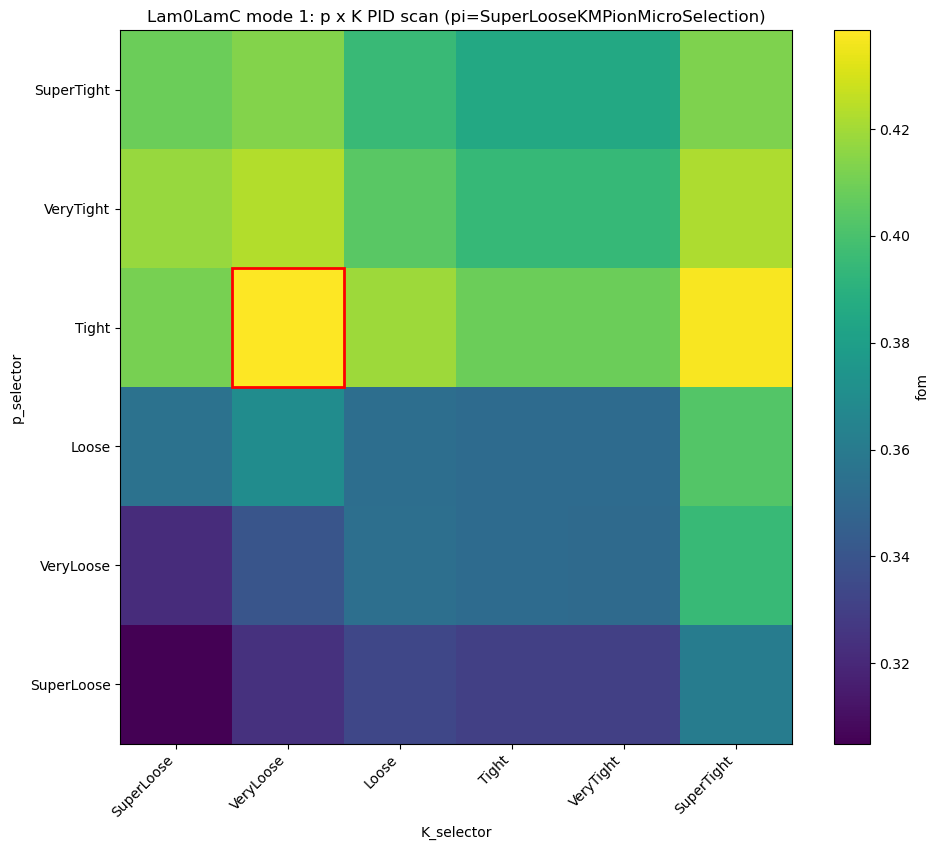

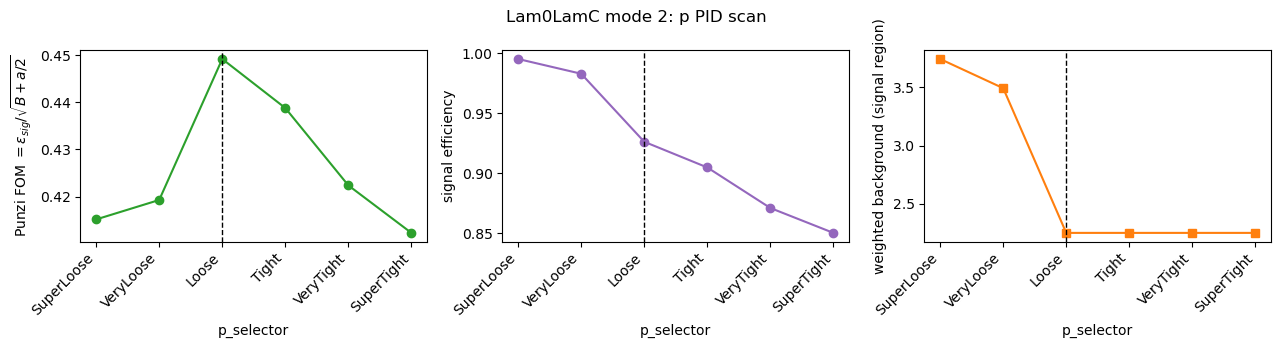

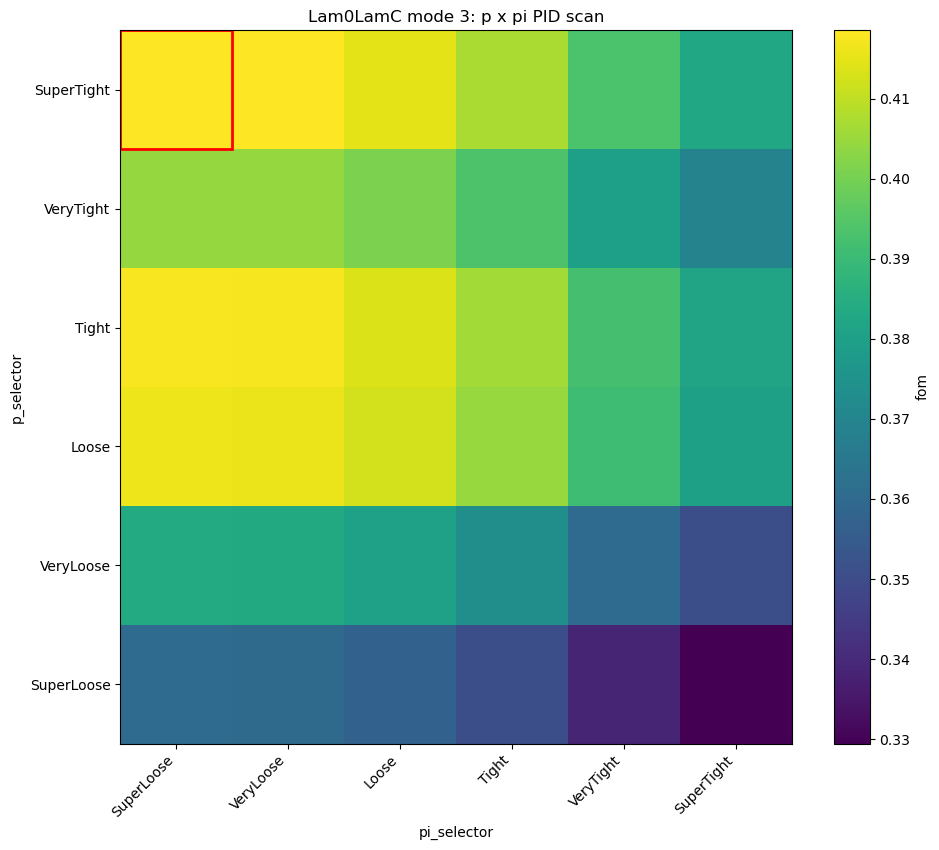

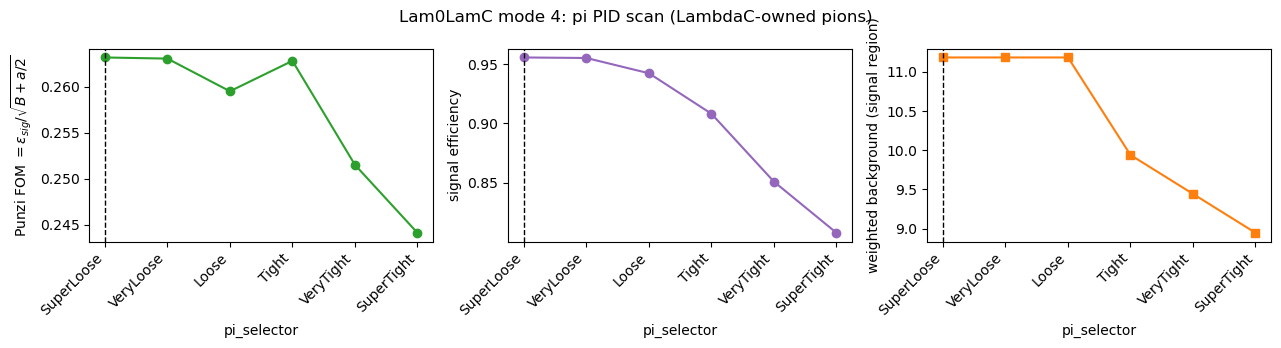

In [7]:
# Plots: 2D heatmap for two-particle scans (mode 1's p x K slice at its
# recommended pi rung; mode 3's p x pi); 1D line for the single-particle
# scans (mode 2's p only, mode 4's pi only).
if CHANNEL == 'Lam0LamC':
    fig_dir = plotting.plot_dir(config)

    df1 = lambdac_dfs[1]
    sel1 = lambdac_selector_per_mode[1]
    df1_slice = df1[df1['pi_selector'] == sel1['pi']]
    plotting.plot_pid_ladder_scan_2d(df1_slice, 'p_selector', 'p_selector_idx', 'K_selector', 'K_selector_idx',
                                      chosen=(sel1['p'], sel1['K']),
                                      title=f"{CHANNEL} mode 1: p x K PID scan (pi={sel1['pi']})")
    plt.savefig(f"{fig_dir}/lambdac_mode1_pid_scan.png", dpi=150)

    plotting.plot_pid_ladder_scan_1d(lambdac_dfs[2], 'p_selector', 'p_selector_idx',
                                      chosen_selector=lambdac_selector_per_mode[2]['p'],
                                      title=f'{CHANNEL} mode 2: p PID scan')
    plt.savefig(f"{fig_dir}/lambdac_mode2_pid_scan.png", dpi=150)

    sel3 = lambdac_selector_per_mode[3]
    plotting.plot_pid_ladder_scan_2d(lambdac_dfs[3], 'p_selector', 'p_selector_idx', 'pi_selector', 'pi_selector_idx',
                                      chosen=(sel3['p'], sel3['pi']),
                                      title=f'{CHANNEL} mode 3: p x pi PID scan')
    plt.savefig(f"{fig_dir}/lambdac_mode3_pid_scan.png", dpi=150)

    plotting.plot_pid_ladder_scan_1d(lambdac_dfs[4], 'pi_selector', 'pi_selector_idx',
                                      chosen_selector=lambdac_selector_per_mode[4]['pi'],
                                      title=f'{CHANNEL} mode 4: pi PID scan (LambdaC-owned pions)')
    plt.savefig(f"{fig_dir}/lambdac_mode4_pid_scan.png", dpi=150)

## Multi-candidate study, with Stage 3 PID applied (Phase 3)

`run_stage03.multi_candidate_numbers_with_pid` redoes Stage 2's
multi-candidate study (B/LambdaC/Lambda0 candidate multiplicities) with the
Stage 3 recommended PID selectors folded in on top of the Stage 2 purity
cuts. **Numbers only** -- no candidate-selection policy (STATUS.md open
decision 1); this compares against the Stage 2 baseline already recorded in
`results/<channel>.yaml`.

Good-B-candidate fractions -- Stage 2 (purity only) vs. Stage 3 (+ recommended PID):
  0 good B:   16.3%  ->   32.4%
  1 good B:   75.4%  ->   62.6%
  >1 good B:   8.3%  ->    5.0%

Good-B candidates by LambdaC mode (Stage 3, PID applied): {1: 24352, 2: 23558, 3: 16019, 4: 19031}
Good-LambdaC candidates by mode (Stage 3, PID applied):   {1: 29160, 2: 27975, 3: 19112, 4: 22929}

Lambda0 (from B) multiplicity distribution:       {0: 18120, 1: 93610, 2: 759, 3: 2}
Lambda0 (from LambdaC, mode 4) multiplicity dist.: {0: 95906, 1: 15906, 2: 679}


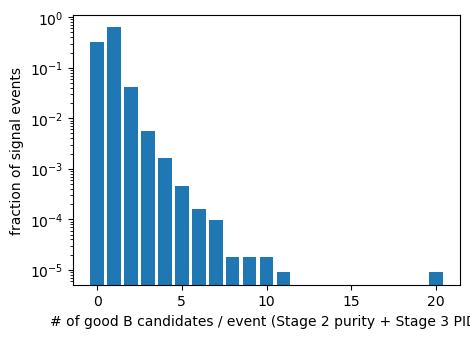

In [8]:
mc_with_pid = rs3.multi_candidate_numbers_with_pid(
    data_sp, config, lambda0_selector, lambdac_selector_per_mode if CHANNEL == 'Lam0LamC' else None)

stage02_results = results_io.load_results(CHANNEL).get('stage02', {})
mc_stage02 = stage02_results.get('multi_candidate_study', {})

print("Good-B-candidate fractions -- Stage 2 (purity only) vs. Stage 3 (+ recommended PID):")
print(f"  0 good B:  {100*mc_stage02.get('frac_zero_good_B', float('nan')):5.1f}%  ->  "
      f"{100*mc_with_pid['frac_zero_good_B']:5.1f}%")
print(f"  1 good B:  {100*mc_stage02.get('frac_one_good_B', float('nan')):5.1f}%  ->  "
      f"{100*mc_with_pid['frac_one_good_B']:5.1f}%")
print(f"  >1 good B: {100*mc_stage02.get('frac_multi_good_B', float('nan')):5.1f}%  ->  "
      f"{100*mc_with_pid['frac_multi_good_B']:5.1f}%")

if CHANNEL == 'Lam0LamC':
    print(f"\nGood-B candidates by LambdaC mode (Stage 3, PID applied): {mc_with_pid['n_good_B_by_lambdac_mode']}")
    print(f"Good-LambdaC candidates by mode (Stage 3, PID applied):   {mc_with_pid['n_good_LambdaC_by_mode']}")
    print(f"\nLambda0 (from B) multiplicity distribution:       {mc_with_pid['n_good_Lambda0_from_B_distribution']}")
    print(f"Lambda0 (from LambdaC, mode 4) multiplicity dist.: {mc_with_pid['n_good_Lambda0_from_LambdaC_distribution']}")

vals = sorted(mc_with_pid['n_good_B_distribution'].keys())
counts = [mc_with_pid['n_good_B_distribution'][v] for v in vals]
plt.figure(figsize=(5, 3.5))
plt.bar(vals, np.array(counts) / mc_with_pid['n_signal_events'])
plt.xlabel('# of good B candidates / event (Stage 2 purity + Stage 3 PID)')
plt.ylabel('fraction of signal events')
plt.yscale('log')
plt.savefig(f"{plotting.plot_dir(config)}/multi_candidate_study_with_pid.png", dpi=150)

## Recommended `channel_config.py` updates

In [9]:
print("pid:")
print(f"  lambda0_selector = {lambda0_selector}")
if CHANNEL == 'Lam0LamC':
    print(f"  lambdac_selector_per_mode = {lambdac_selector_per_mode}")

print("\nThese are NOT yet written into channel_config.py -- review at this "
      "checkpoint, then apply (Claude can do this on request) before Stage 4.")

pid:
  lambda0_selector = {'p': 'SuperLooseKMProtonSelection', 'pi': 'SuperLooseKMPionMicroSelection'}
  lambdac_selector_per_mode = {1: {'K': 'VeryLooseKMKaonMicroSelection', 'p': 'TightKMProtonSelection', 'pi': 'SuperLooseKMPionMicroSelection'}, 2: {'p': 'LooseKMProtonSelection'}, 3: {'p': 'SuperTightKMProtonSelection', 'pi': 'SuperLooseKMPionMicroSelection'}, 4: {'pi': 'SuperLooseKMPionMicroSelection'}}

These are NOT yet written into channel_config.py -- review at this checkpoint, then apply (Claude can do this on request) before Stage 4.


## Observations / checkpoint summary

- **Do the $\Lambda^0$ PID scans (both channels) show a clear interior FOM
  maximum, or a boundary-hugging optimum?**

  Boundary-hugging at the *loosest* rung (SuperLoose p + SuperLoose pi) for
  **both** channels. Explicit check against applying no PID cut at all
  confirms this is a genuine, if modest, improvement over no cut at all
  (Lam0Lam0: FOM 0.364 vs. 0.229 with no cut; Lam0LamC: 0.082 vs. 0.081 --
  much smaller margin there) -- so the true optimum plausibly lies *outside*
  the KM ladder entirely, at an even looser (or no) PID requirement, not at
  a real interior trade-off within the ladder. Unlike Stage 2's
  boundary-hugging issue (traced to an upstream mass-skim depleting the
  sidebands), this one has a simpler explanation: the background already
  surviving the Stage 1/2 purity cuts, in the signal box, is low enough
  relative to signal that any further efficiency loss from tightening PID
  isn't worth the marginal background rejection.

- **`Lam0LamC`: do the LambdaC per-mode scans look sane?**

  Mixed. Mode 2 (p K_S0) gives a genuine **interior** optimum (Loose proton,
  not boundary-hugging) -- the one clean result, same reassuring pattern as
  Stage 2's one clean scan. Mode 1 (p K- pi+) is a partial success: the p
  and K dimensions both land on clean interior optima (Tight proton, Very
  Loose kaon), but the pi dimension still wants to stay at the loosest rung.
  Modes 3 and 4 are boundary-hugging in every scanned dimension (mode 3:
  proton wants *tightest*, pion wants *loosest* -- an interesting split
  suggesting mode 3's dominant background may be proton-fake-driven rather
  than pion-driven, not yet investigated further).

- **Low-MC-statistics flag**: none of the recommended operating points
  triggered `low_mc_stats` (background-MC raw candidate counts at the
  recommended cut ranged from 6-333 across all scans) -- the boundary-hugging
  above reflects the FOM's shape, not a noisy few-MC-candidate denominator.

- **Multi-candidate study (Phase 3), `Lam0LamC`**: adding the Stage 3
  recommended PID selectors on top of Stage 2's purity cuts moves the
  good-B-candidate fractions from (16.3% / 75.4% / 8.3%) to roughly
  (32% / 63% / 5%) for (0 / 1 / >1) good B candidates -- PID removes a
  sizeable chunk of previously-good candidates entirely (mostly via the
  LambdaC per-mode cuts, since the Lambda0 selector is the loosest KM rung
  and costs little), and reduces the multi-candidate fraction somewhat
  (8.3% -> 5%) but does not resolve it -- consistent with STATUS.md's parked
  single-candidate decision (open decision 1), presented here for Matt's
  review, not decided.

- **Before applying anything**: given how many of these are boundary-hugging
  at the loosest rung, worth deciding together whether "no PID cut" is
  preferable to "loosest KM selector" for the Lambda0 daughters and LambdaC
  modes 3/4's pions, rather than mechanically applying the ladder's edge
  value.

- [ ] Apply the recommended values (or "no cut", per the above) to
  `channel_config.py`'s `pid` section (ask Claude to do this once decided),
  then re-run `run_stage03.py` to refresh `results/<channel>.yaml`, and
  `generate_latex_macros.py` to refresh the BAD.

**Next steps:** review at this checkpoint, decide which PID cuts (if any) to
apply, then Stage 4 (antibaryon veto).